# Hopfield's Artificial Neural Networks

In [1]:
import modules.hopfield_network as hp
import matplotlib.pyplot as plt
import numpy as np
import random

## Network Training Pipeline

### Random Memories (Stability Efficiency)

#### Defining the memories

In [2]:
N = 25 # Number of neurons

P = 2  # Number of memories

random_memories = hp.patterns(P,N)

#### Applying Hebbian's Training Rule

In [3]:
rand_weights = hp.train(N, random_memories)

#### Testing Network

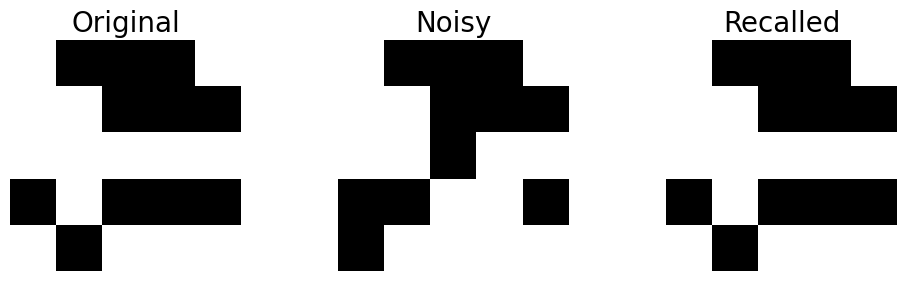

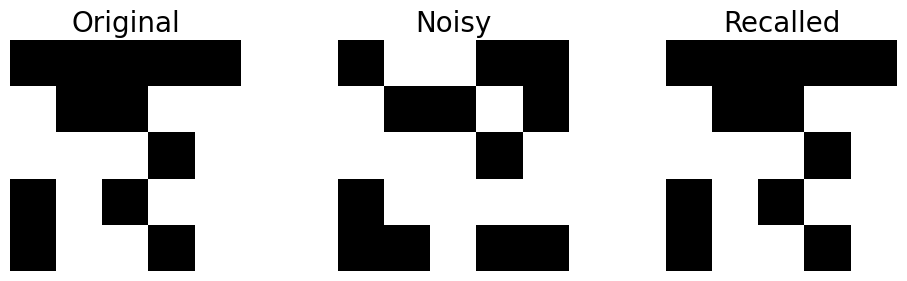

In [4]:
hp.test_network(random_memories, rand_weights, 0.25, label = "random_memory")

#### Visualizing our Artificial Intelligence's core

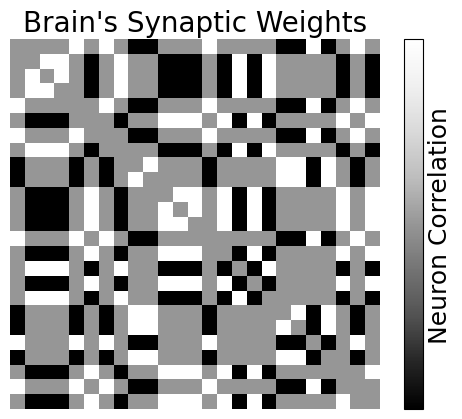

In [5]:
hp.see_synapses(rand_weights,figlabel = "rand_mem_synapses")

### Handpicked Memories (Visually Representative)

#### Pre-process Images

In [6]:
img_ufsc, vetor_ufsc = hp.preprocessar_para_hopfield('dataset/ufsc.png', 
                                                     size=100, 
                                                     threshold=0.6, 
                                                     swap_colors=True)

In [7]:
img_github, vetor_github = hp.preprocessar_para_hopfield('dataset/github.png', 
                                                         size=100, threshold=0.60, 
                                                         swap_colors=True)

In [8]:
img_playstation, vetor_playstation = hp.preprocessar_para_hopfield('dataset/playstation.png', 
                                                                   size=100, 
                                                                   threshold=0.3, 
                                                                   swap_colors=False)

In [9]:
memories = [vetor_ufsc, vetor_github, vetor_playstation]

#### Train

In [10]:
img_weights = hp.train(len(vetor_ufsc), memories)

#### Test

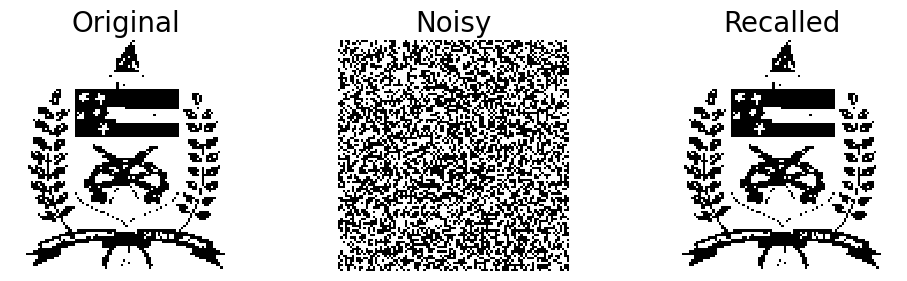

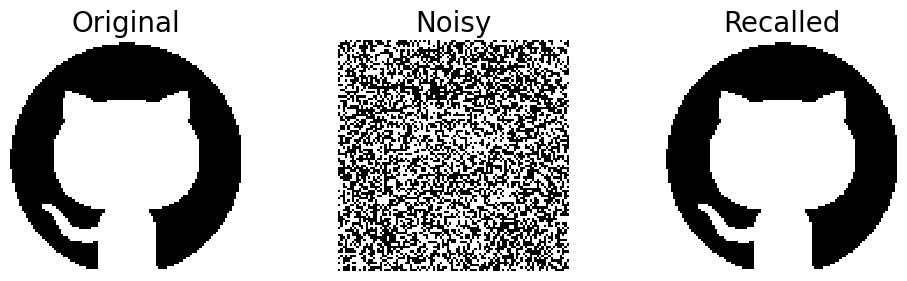

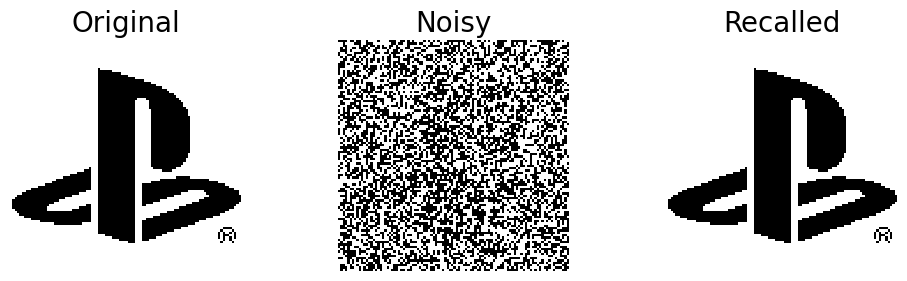

In [11]:
hp.test_network(memories, img_weights, noise_level=0.45, label = "image_memory")

#### Brain

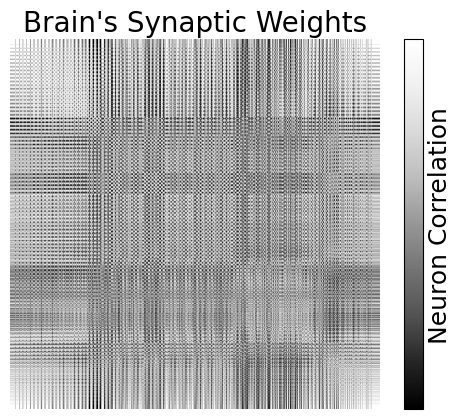

In [12]:
hp.see_synapses(img_weights,figlabel = "image_mem_synapses")

## Error Correction

### Train with Original

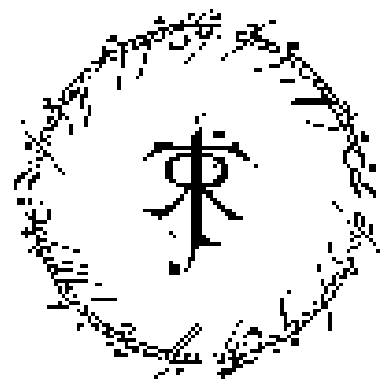

In [13]:
img_tolkien, vetor_tolkien = hp.preprocessar_para_hopfield("dataset/tolkien.png", 
                                                           size = 100, 
                                                           threshold = 0.90,
                                                           swap_colors = True)

img_weights = img_weights + hp.train(len(vetor_tolkien), [vetor_tolkien])

hp.vizualize([vetor_tolkien],[],[], len(vetor_tolkien), save = False, recall = False)

### Simulate Error

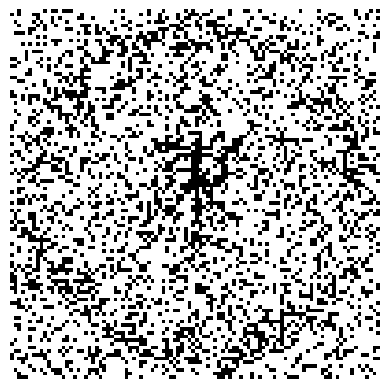

In [14]:
tolkien_wrong = hp.add_noise(vetor_tolkien, noise_level=0.25)

hp.vizualize([tolkien_wrong],[],[], len(tolkien_wrong), save = False, recall = False)

### Retrieve Converged Memory

In [15]:
tolkien_corrected = hp.retrieve(len(vetor_tolkien), img_weights, tolkien_wrong)

Note that, to correct a pattern, we do not need the original, beyond the training phase, which makes perfect sense.

### Visualize Corrected

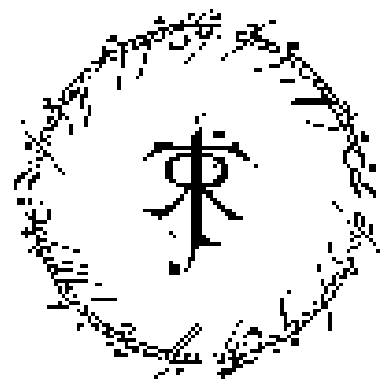

In [16]:
hp.vizualize([tolkien_corrected],[],[], len(tolkien_corrected), save = False, recall = False)

## Energy and Stability

### Hamiltonian

O Hamiltoniano que descreve a energia total da rede para uma dada configuração de spins/neurônios $\vec{\sigma}$ é definido como:

$$ \mathcal{H}(\vec{\sigma}) = -\frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} W_{ij} \sigma_i \sigma_j - \sum_{i=1}^{N} H_i \sigma_i $$

**Definição dos termos:**
* **$\sigma_i \in \{-1, +1\}$:** estado discreto do neurônio $i$.
* **$H_i$:** limiar de ativação (campo magnético externo) no neurônio $i$.
* **$W_{ij}$:** matriz de pesos sinápticos dada pela regra de aprendizado Hebbiana.

#### Forma Alternativa em Função do *Overlap*

Em termos da sobreposição magnética $M^{(\mu)}(\vec{\sigma}) = \frac{1}{N} \sum_{i=1}^N \xi_i^{(\mu)} \sigma_i$ com os $P$ padrões armazenados $\vec{\xi}^{(\mu)}$, a função de energia reduz-se a:

$$ \mathcal{H}(\vec{\sigma}) = -\frac{1}{2} N \sum_{\mu=1}^{P} \left( M^{(\mu)}(\vec{\sigma}) \right)^2 $$

In [17]:
# Exemplo

x = hp.current_energy(img_weights, vetor_tolkien)
y = hp.current_energy(img_weights, tolkien_wrong)

print(f"Energy of the original image: {x:.0f} unidades de energia, u.e.")
print(f"Energy of the erroneous image: {y:.0f} unidades de energia, u.e.")

Energy of the original image: -6560 unidades de energia, u.e.
Energy of the erroneous image: -1659 unidades de energia, u.e.


### Random Network

#### Disorded Axis

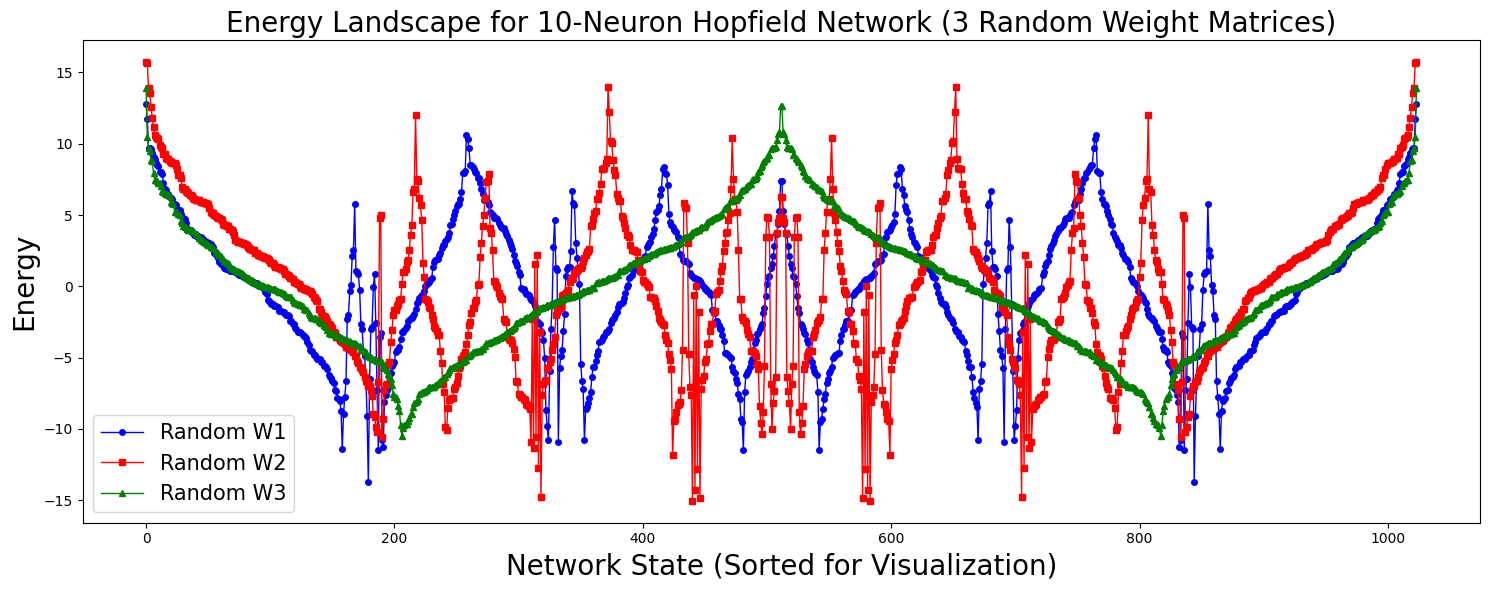

In [ ]:
N = 10 # Number of neurons (adjust as needed, keeping in mind 2^N states)
all_states = hp.all_binary_states(N)
energy_threshold_for_memories = -10 # Adjust as needed for random W

plot_energies1 = []
plot_energies2 = []
plot_energies3 = []

# Generate three random weight matrices and calculate sorted energies
Ws = []
for _ in range(3):
    Ws.append(hp.random_weights(N))

for i, W in enumerate(Ws):
    initial_energies = [hp.current_energy(W, state) for state in all_states]
    identified_memories = hp.extract_memories(W, all_states, energy_threshold=energy_threshold_for_memories)

    # If no memories are identified, sort_states will use its fallback (sort by energy)
    sorted_states = hp.sort_states(all_states, initial_energies, identified_memories)
    sorted_energies = [hp.current_energy(W, s) for s in sorted_states]

    if i == 0:
        plot_energies1 = sorted_energies
    elif i == 1:
        plot_energies2 = sorted_energies
    else:
        plot_energies3 = sorted_energies

# Plotting all three energy landscapes on a single graph
plt.figure(figsize=(15, 6))

plt.plot(plot_energies1, 'o-', color='blue', label='Random W1', markersize=4, linewidth=1)
plt.plot(plot_energies2, 's-', color='red', label='Random W2', markersize=4, linewidth=1)
plt.plot(plot_energies3, '^-', color='green', label='Random W3', markersize=4, linewidth=1)

plt.title(f'Energy Landscape for {N}-Neuron Hopfield Network (3 Random Weight Matrices)',fontsize=20)
plt.xlabel('Network State (Sorted for Visualization)',fontsize=20)
plt.ylabel('Energy',fontsize=20)
plt.legend(fontsize = 15)
#plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("figures/random_disordered_energy.png", dpi=400)
plt.show()

#### Ordered Axis

To order the axis and see basins of attraction, we need the following procedure:

##### Extract Memories from W

##### Order State Axis Based on the Extracted Memories

##### Visualize Energy Landscape

### Trainded Network

#### Disorded Axis

#### Ordered Axis

## Statistics and Hallucination Band: